In [1]:
from pathlib import Path

import ee
import geemap
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from psmpy import PsmPy

from belo_horizonte.bounds import load_bounds
from belo_horizonte.sample import (
    sample_elevation,
    sample_lights,
    sample_lots,
    sample_slope,
)
from belo_horizonte.temperature import get_lst

In [11]:
PROJECT_NAME = "ee-ursa-test"

ee.Initialize(project=PROJECT_NAME)

In [3]:
data_path = Path("./data")

# Bounds

In [4]:
bounds_ee = load_bounds(data_path)

# Temperature

In [6]:
lst = get_lst(
    col_name="LANDSAT/LE07/C02/T1_L2",
    year=2000,
    temp_band="ST_B6",
    qa_band="QA_PIXEL",
    bounds=bounds_ee,
)

for year in range(2001, 2020):
    lst = lst.addBands(
        get_lst(
            col_name="LANDSAT/LE07/C02/T1_L2",
            year=year,
            temp_band="ST_B6",
            qa_band="QA_PIXEL",
            bounds=bounds_ee,
        ),
    )

In [7]:
lst_2020 = get_lst(
    col_name="LANDSAT/LC08/C02/T1_L2",
    year=2020,
    temp_band="ST_B10",
    qa_band="QA_PIXEL",
    bounds=bounds_ee,
)
lst_2020_reprojected = lst_2020.setDefaultProjection(crs="EPSG:32623", scale=30)

res = lst_2020.reduceRegion(
    ee.reducer.Reducer.percentile([2, 98]),
    bounds_ee,
    30,
).getInfo()

if res is None:
    err = "Failed to compute percentiles for LST 2020. Check if the image collection is empty or if the bounds are correct."
    raise ValueError(err)

vmin = res["b2020_p2"]
vmax = res["b2020_p98"]

m = geemap.Map(center=[-19.9207, -43.9378], zoom=12)
m.addLayer(lst_2020.clip(bounds_ee), {"min": vmin, "max": vmax, "palette": "Reds"})
m.addLayer(
    lst_2020_reprojected.clip(bounds_ee),
    {"min": vmin, "max": vmax, "palette": "Reds"},
)
m

Map(center=[-19.9207, -43.9378], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

# Greening

In [8]:
img = (
    ee.imagecollection.ImageCollection("users/Caoyue/greening/Green_B")
    .filterBounds(bounds_ee)
    .mosaic()
)

gain_yod = img.select("gain_yod")
loss_yod = img.select("loss_yod")
mix = gain_yod.updateMask(loss_yod.gt(0)).unmask(0)

greening = gain_yod.updateMask(mix.eq(0)).clamp(0, 1).rename("type")
browning = loss_yod.updateMask(mix.eq(0)).clamp(0, 1).multiply(2).rename("type")
green_and_brown = greening.unmask().add(browning.unmask(0)).selfMask()

# Tree canopy

In [9]:
img_canopy = (
    ee.ImageCollection("projects/sat-io/open-datasets/facebook/meta-canopy-height")
    .filterBounds(bounds_ee)
    .first()
)

## Masks

In [ ]:
existing_heights = [
    int(x["name"].split("/")[-1].split("_")[-1])
    for x in ee.data.listAssets(f"projects/{PROJECT_NAME}/assets/belo_horizonte")[
        "assets"
    ]
]

tasks = []
for i in range(3, 20):
    if i in existing_heights:
        continue

    img_temp = (
        img_canopy.gte(i)
        .reduceResolution(reducer=ee.reducer.Reducer.mean(), maxPixels=1024)
        .multiply(ee.image.Image.pixelArea())
        .reproject(lst_2020_reprojected.projection())
        .clip(bounds_ee)
    )

    task = ee.batch.Export.image.toAsset(
        img_temp,
        assetId=f"projects/{PROJECT_NAME}/assets/belo_horizonte/height_{i}",
        description=f"height_{i}",
    )
    tasks.append(task)

In [37]:
canopy_mask = (
    ee.image.Image("projects/ee-ursa-test/assets/belo_horizonte/height_3")
    .divide(900)
    .clamp(0, 1)
    .lt(0.25)
    .add(1)
    .rename(["type"])
)

In [38]:
m = geemap.Map(center=[-19.9207, -43.9378], zoom=12)
m.addLayer(
    green_and_brown.clip(bounds_ee),
    {"palette": ["green", "brown"], "min": 1, "max": 2},
)
m.addLayer(
    canopy_mask.clip(bounds_ee),
    {"palette": ["blue", "red"], "min": 1, "max": 2},
)
m

Map(center=[-19.9207, -43.9378], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

# Samples

## Points

In [ ]:
# 1: treatment 2: control

df_samples = (
    ee.data.computeFeatures(
        {
            "expression": ee.image.Image.constant(1)
            .addBands(canopy_mask)
            .stratifiedSample(
                numPoints=200,
                classBand="type",
                region=bounds_ee,
                scale=30,
                geometries=True,
                seed=42,
                classValues=[2],
                classPoints=[5000],
            ),
            "fileFormat": "GEOPANDAS_GEODATAFRAME",
        },
    )
    .drop(columns=["constant"])
    .pipe(lambda df: df.set_crs("EPSG:4326"))
    .assign(type=lambda df: df["type"].map({1: 1, 2: 0}))
)

crs = df_samples.estimate_utm_crs()
df_samples = df_samples.to_crs(crs)

col_samples = geemap.geopandas_to_ee(
    df_samples.to_crs("EPSG:4326")[["geometry"]].reset_index(names="index"),
)

## Temperature

In [64]:
start_end_temps = (
    ee.data.computeFeatures(
        {
            "expression": lst.select(["b2000", "b2019"]).sampleRegions(
                col_samples,
                scale=30,
            ),
            "fileFormat": "GEOPANDAS_GEODATAFRAME",
        },
    )
    .set_index("index")
    .drop(columns=["geometry"])
    .rename(columns={"b2000": "start_temp", "b2019": "end_temp"})
)

df_samples = df_samples.drop(columns=["start_temp", "end_temp"], errors="ignore").join(
    start_end_temps,
)

<Axes: xlabel='diff', ylabel='Density'>

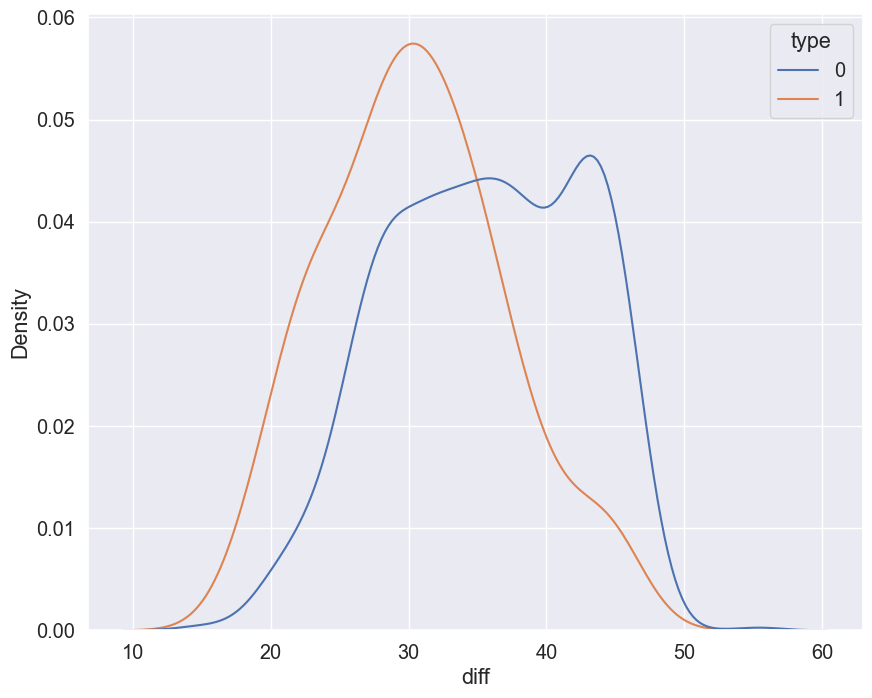

In [65]:
sns.kdeplot(
    df_samples.assign(diff=lambda df: df["end_temp"]),
    x="diff",
    hue="type",
    common_norm=False,
)

## Elevation

In [66]:
df_samples = df_samples.assign(
    elevation=lambda df: sample_elevation(df, data_path),
    slope=lambda df: sample_slope(df, data_path),
    lights=sample_lights(col_samples, bounds_ee),
)

df_samples = df_samples.join(sample_lots(df_samples, data_path))

## Save

In [185]:
df_samples.drop(columns=["geometry"]).to_csv("./df.csv", index=False)
df_samples.to_file("./df_samples.gpkg", driver="GPKG")

# Matching

In [186]:
not_matched = (
    df_samples.reset_index(names="index").drop(columns=["geometry"])
    # .dropna(subset=["start_temp"])
)

psm = PsmPy(
    not_matched,
    treatment="type",
    indx="index",
    exclude=["end_temp", "start_temp"],
    seed=42,
)
psm.logistic_ps(balance=True)
psm.kdtree_matched(
    matcher="propensity_logit",
    replacement=False,
    caliper=0.05,
    drop_unmatched=True,
)

<Axes: xlabel='propensity_logit', ylabel='Density'>

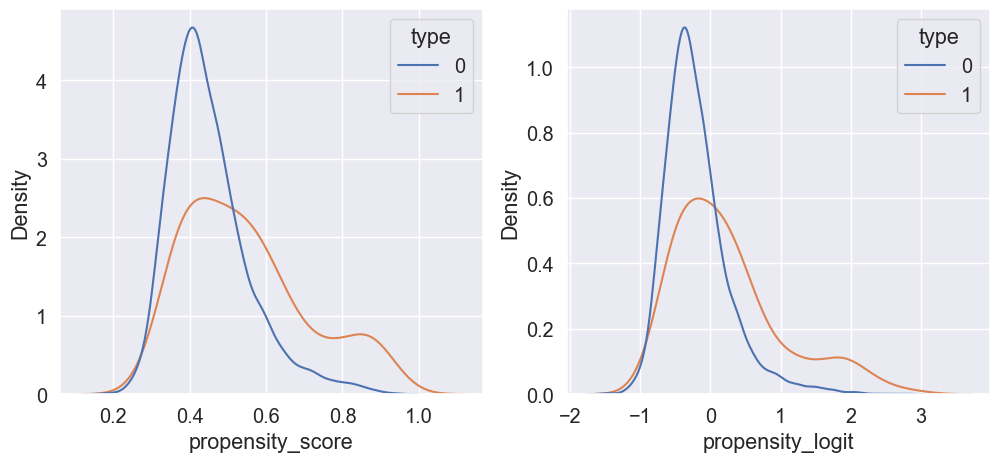

In [187]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(
    psm.predicted_data,
    hue="type",
    x="propensity_score",
    ax=axl,
    common_norm=False,
)
sns.kdeplot(
    psm.predicted_data,
    hue="type",
    x="propensity_logit",
    ax=axr,
    common_norm=False,
)

In [188]:
matched_treatment = df_samples.loc[psm.matched_ids["matched_ID"]]
matched_control = df_samples.loc[psm.matched_ids["index"]]
matched = pd.concat([matched_treatment, matched_control])

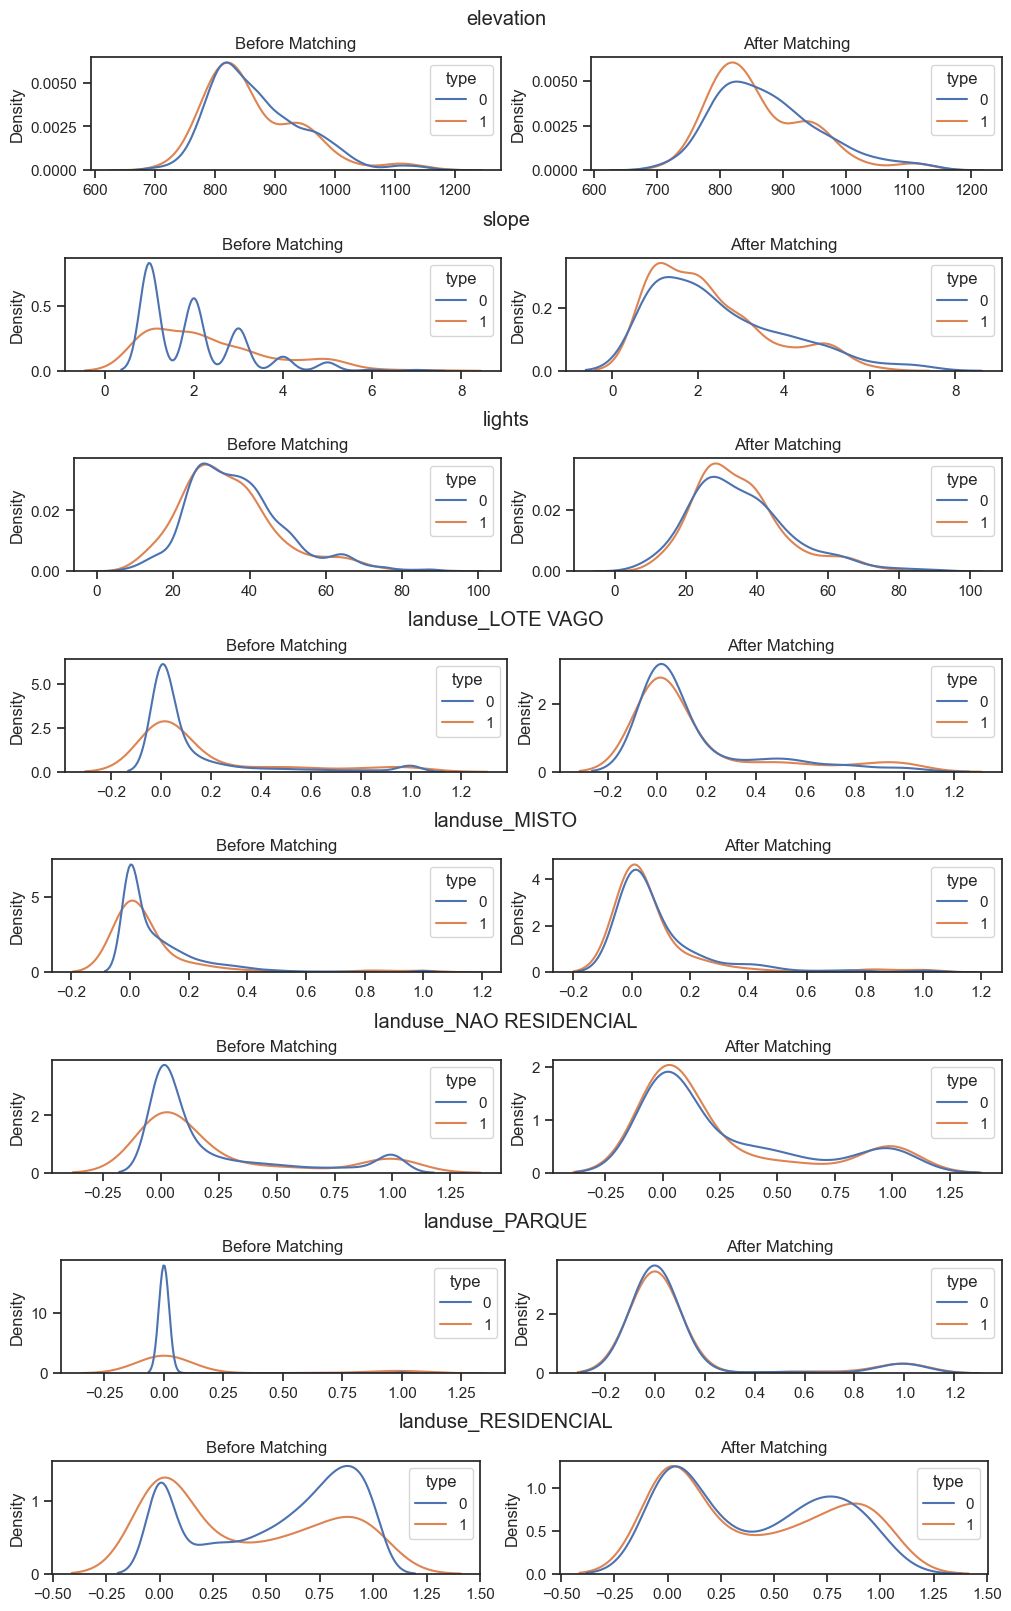

In [189]:
sns.set_theme(style="ticks")

wanted_cols = df_samples.columns.drop(["type", "geometry", "start_temp", "end_temp"])

fig = plt.figure(figsize=(10, 2 * len(wanted_cols)), constrained_layout=True)
subfigs = fig.subfigures(len(wanted_cols), 1)

for var, subfig in zip(wanted_cols, subfigs, strict=False):
    axl, axr = subfig.subplots(1, 2)
    sns.kdeplot(data=not_matched, x=var, hue="type", ax=axl, common_norm=False)
    sns.kdeplot(data=matched, x=var, hue="type", ax=axr, common_norm=False)

    # sns.histplot(data=not_matched, x=var, hue="type", ax=axl, common_norm=False, stat="density", legend=False)
    # sns.histplot(data=matched, x=var, hue="type", ax=axr, common_norm=False, stat="density", legend=False)

    axl.set_title("Before Matching")
    axr.set_title("After Matching")
    axl.set_xlabel("")
    axr.set_xlabel("")
    subfig.suptitle(var)

<Axes: xlabel='end_temp'>

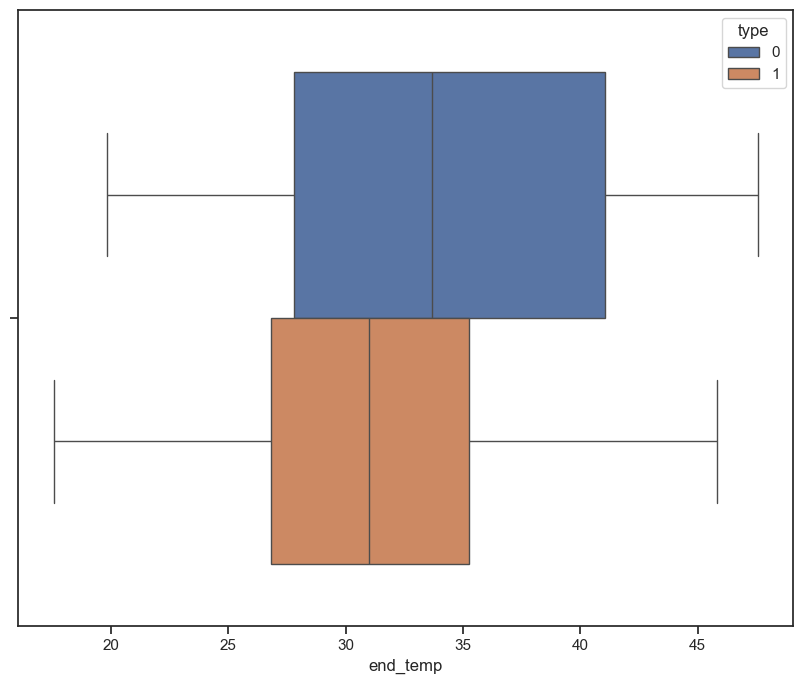

In [191]:
test = matched.assign(diff=lambda df: df["start_temp"] - df["end_temp"])
sns.boxplot(test, x="end_temp", hue="type")